# Phase 2 Overview Notebook: Preprocessing, Activity Audit & Language-Region Analysis

This notebook provides an interactive environment to inspect and validate Phase 2 v2 preprocessing:
1. **Multivariable Activity Audit**: empirical thresholding (>9.0 tweets/day P99.5).
2. **Exact Duplicate Removal**: retaining original retweets as intensity metric.
3. **Text Cleaning**: VADER/RoBERTa-safe text normalization.
4. **Package D Language-Region Analysis**: Cross-tabulating user US states vs detected language.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
PROJECT_ROOT = Path("..").resolve()
P2_DATA_DIR = PROJECT_ROOT / "data" / "02_interim" / "phase2_v2"
P2_RESULTS_DIR = PROJECT_ROOT / "output" / "results" / "phase2" / "v2"

manifest = json.loads((P2_RESULTS_DIR / "preprocessing_manifest_v2.json").read_text())
print("Phase 2 Manifest Summary:")
print(json.dumps(manifest, indent=2))

Phase 2 Manifest Summary:
{
  "phase": "phase2_preprocessing_v2",
  "run_id": "phase2_v2_multivariable_20260731",
  "initial_record_count": 1747542,
  "selected_activity_threshold": 9.0,
  "users_examined": 483175,
  "high_volume_users_removed": 2227,
  "tweets_removed_activity_filter": 222366,
  "tweets_removed_exact_duplicate_filter": 193831,
  "tweets_removed_text_cleaning": 0,
  "final_cleaned_record_count": 1331345,
  "retention_pct": 76.18386281989217,
  "package_d_language_region_summary": {
    "total_tweets": 1331345,
    "us_state_tweets": 273362,
    "us_spanish_tweets": 0,
    "us_other_language_tweets": 0,
    "unmapped_tweets": 915190
  },
  "output_paths": {
    "cleaned_parquet": "D:\\GW_UNIVERSITY\\AIS\\Social_Listener\\Env\\Social_Listener_V1\\UOG_AIS_SOCIAL_LISTENER\\data\\02_interim\\phase2_v2\\twitter_cleaned_v2.parquet",
    "manifest": "D:\\GW_UNIVERSITY\\AIS\\Social_Listener\\Env\\Social_Listener_V1\\UOG_AIS_SOCIAL_LISTENER\\output\\results\\phase2\\v2\\preproce

## 1. Load Cleaned Dataset (`twitter_cleaned_v2.parquet`)

In [2]:
cleaned_df = pd.read_parquet(P2_DATA_DIR / "twitter_cleaned_v2.parquet")
print(f"Cleaned Record Count: {len(cleaned_df):,}")
cleaned_df.head(5)

Cleaned Record Count: 1,331,345


,tweet_id,id,created_at,date,tweet,likes,retweet_count,retweets,replies,source,...,city,country,continent,state,state_code,collected_at,candidate_stream,candidate,source_file,tweet_cleaned
0,1.316529221557252e+18,1.316529221557252e+18,2020-10-15 00:00:01+00:00,2020-10-15 00:00:01+00:00,#Elecciones2020 | En #Florida: #JoeBiden dice ...,0.0,0.0,0.0,None,TweetDeck,...,,United States of America,North America,Florida,FL,2020-10-21 00:00:00+00:00,donald_trump,donald_trump,hashtag_donaldtrump.csv,#Elecciones2020 | En #Florida: #JoeBiden dice ...
1,1.3165292227484303e+18,1.3165292227484303e+18,2020-10-15 00:00:01+00:00,2020-10-15 00:00:01+00:00,"Usa 2020, Trump contro Facebook e Twitter: cop...",26.0,9.0,9.0,None,Social Mediaset,...,,,,,,2020-10-21 00:00:00.373216530+00:00,donald_trump,donald_trump,hashtag_donaldtrump.csv,"Usa 2020, Trump contro Facebook e Twitter: cop..."
2,1.3165292523014513e+18,1.3165292523014513e+18,2020-10-15 00:00:08+00:00,2020-10-15 00:00:08+00:00,You get a tie! And you get a tie! #Trump ‘s ra...,4.0,3.0,3.0,None,Twitter for iPhone,...,Washington,United States of America,North America,District of Columbia,DC,2020-10-21 00:00:01.492866121+00:00,donald_trump,donald_trump,hashtag_donaldtrump.csv,You get a tie! And you get a tie! #Trump ‘s ra...
3,1.316529291052675e+18,1.316529291052675e+18,2020-10-15 00:00:17+00:00,2020-10-15 00:00:17+00:00,@CLady62 Her 15 minutes were over long time ag...,2.0,0.0,0.0,None,Twitter for Android,...,,United States of America,North America,California,CA,2020-10-21 00:00:01.866082651+00:00,donald_trump,donald_trump,hashtag_donaldtrump.csv,@CLady62 Her 15 minutes were over long time ag...
4,1.316529289949569e+18,1.316529289949569e+18,2020-10-15 00:00:17+00:00,2020-10-15 00:00:17+00:00,@richardmarx Glad u got out of the house! DICK...,0.0,0.0,0.0,None,Twitter for iPhone,...,,,,,,2020-10-21 00:00:02.239299182+00:00,donald_trump,donald_trump,hashtag_donaldtrump.csv,@richardmarx Glad u got out of the house! DICK...


## 2. Retention Funnel Analysis

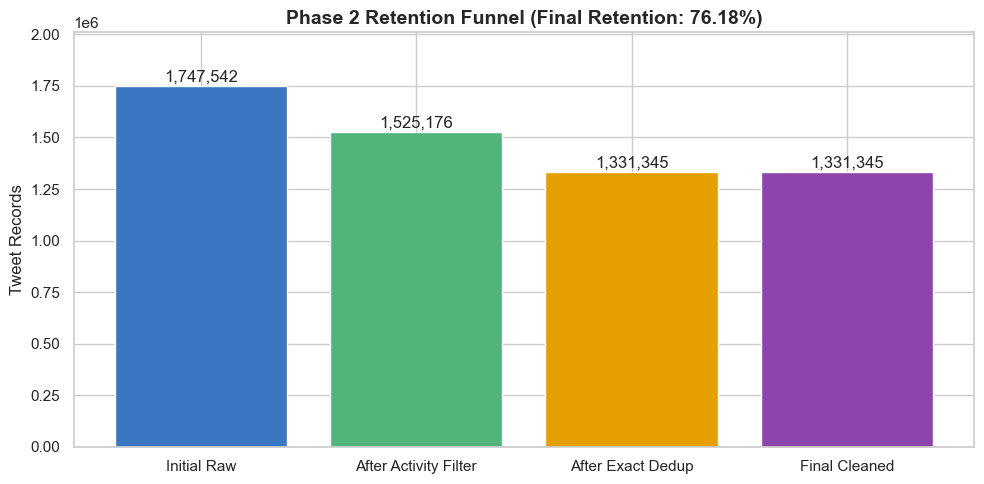

In [3]:
stages = ["Initial Raw", "After Activity Filter", "After Exact Dedup", "Final Cleaned"]
counts = [
    manifest["initial_record_count"],
    manifest["initial_record_count"] - manifest["tweets_removed_activity_filter"],
    manifest["initial_record_count"] - manifest["tweets_removed_activity_filter"] - manifest["tweets_removed_exact_duplicate_filter"],
    manifest["final_cleaned_record_count"]
]

plt.figure(figsize=(10, 5))
bars = plt.bar(stages, counts, color=["#3977C3", "#50B47B", "#E69F00", "#8E44AD"])
plt.title(f"Phase 2 Retention Funnel (Final Retention: {manifest['retention_pct']:.2f}%)", fontsize=14, fontweight="bold")
plt.ylabel("Tweet Records", fontsize=12)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10000, f"{int(height):,}", ha="center", va="bottom")
plt.ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()

## 3. Package D Language-Region Cross-Tabulation

In [4]:
pkg_d = manifest["package_d_language_region_summary"]
df_pkg_d = pd.DataFrame(list(pkg_d.items()), columns=["Metric", "Count"])
df_pkg_d

,Metric,Count
0,total_tweets,1331345
1,us_state_tweets,273362
2,us_spanish_tweets,0
3,us_other_language_tweets,0
4,unmapped_tweets,915190
